In [1]:
println("$(Threads.nthreads()) Threads")
if Threads.nthreads() == 1
    println("Not running in parallel")
end

8 Threads


In [2]:
using Plots
using StatsPlots
using FileIO
include("hmm.jl")

run_hmm_em_stay_spatial (generic function with 1 method)

In [3]:
using EM

In [4]:
function show_results(results; mu=true, sigma=true)
    io = IOBuffer()
    
    print(io, "<pre>")
    print(io, "$(results.varnames)\n")
    print(io, "</pre>")

    if mu
        print(io, "β:<br/>")
        print(io, "<pre>")
        show(io, MIME"text/plain"(), round.(results.betas; digits=2))
        print(io, "</pre>")
    end
    
    if sigma
        print(io, "σ²:<br/>")
        print(io, "<pre>")
        show(io, MIME"text/plain"(), round.(results.sigma; digits=2))
        print(io, "</pre>")
    end
    
    my_string = String(take!(io))
    my_string = replace(my_string, r"[0-9]+×[0-9]+ Matrix{Float64}:\n" => "")
    my_string = replace(my_string, r"(-[0-9\.]+)" => s"<span style='color: red'>\1</span>")
    my_string = replace(my_string, "\n" => "<br/>")
    
    my_string
end

show_results (generic function with 1 method)

In [5]:
hmm_em_stay_spatial_peanut = run_hmm_em_stay_spatial("peanut")
# hmm_em_stay_turn_peanut = run_hmm_em_stay_turn("peanut")
# hmm_em_stay_peanut = run_hmm_em_stay("peanut")
# hmm_em_peanut = run_hmm_em("peanut")
save("results/hmm_em_stay_spatial_peanut.jld2", "hmm_em_stay_spatial_peanut", hmm_em_stay_spatial_peanut)
# save("results/hmm_em_stay_turn_peanut.jld2", "hmm_em_stay_turn_peanut", hmm_em_stay_turn_peanut)
# save("results/hmm_em_stay_peanut.jld2", "hmm_em_stay_peanut", hmm_em_stay_peanut)
# save("results/hmm_em_peanut.jld2", "hmm_em_peanut", hmm_em_peanut)

In [6]:
hmm_em_stay_spatial_wilbur = run_hmm_em_stay_spatial("wilbur")
# hmm_em_stay_turn_wilbur = run_hmm_em_stay_turn("wilbur")
# hmm_em_stay_wilbur = run_hmm_em_stay("wilbur")
# hmm_em_wilbur = run_hmm_em("wilbur")
save("results/hmm_em_stay_spatial_wilbur.jld2", "hmm_em_stay_spatial_wilbur", hmm_em_stay_spatial_wilbur)
# save("results/hmm_em_stay_turn_wilbur.jld2", "hmm_em_stay_turn_wilbur", hmm_em_stay_turn_wilbur)
# save("results/hmm_em_stay_wilbur.jld2", "hmm_em_stay_wilbur", hmm_em_stay_wilbur)
# save("results/hmm_em_wilbur.jld2", "hmm_em_wilbur", hmm_em_wilbur)

In [7]:
hmm_em_stay_spatial_senor = run_hmm_em_stay_spatial("senor")
# hmm_em_stay_turn_senor = run_hmm_em_stay_turn("senor")
# hmm_em_stay_senor = run_hmm_em_stay("senor")
# hmm_em_senor = run_hmm_em("senor")
save("results/hmm_em_stay_spatial_senor.jld2", "hmm_em_stay_spatial_senor", hmm_em_stay_spatial_senor)
# save("results/hmm_em_stay_turn_senor.jld2", "hmm_em_stay_turn_senor", hmm_em_stay_turn_senor)
# save("results/hmm_em_stay_senor.jld2", "hmm_em_stay_senor", hmm_em_stay_senor)
# save("results/hmm_em_senor.jld2", "hmm_em_senor", hmm_em_senor)

In [8]:
hmm_em_stay_spatial_j16 = run_hmm_em_stay_spatial("j16")
# hmm_em_stay_turn_j16 = run_hmm_em_stay_turn("j16")
# hmm_em_stay_j16 = run_hmm_em_stay("j16")
# hmm_em_j16 = run_hmm_em("j16")
save("results/hmm_em_stay_spatial_j16.jld2", "hmm_em_stay_spatial_j16", hmm_em_stay_spatial_j16)
# save("results/hmm_em_stay_turn_j16.jld2", "hmm_em_stay_turn_j16", hmm_em_stay_turn_j16)
# save("results/hmm_em_stay_j16.jld2", "hmm_em_stay_j16", hmm_em_stay_j16)
# save("results/hmm_em_j16.jld2", "hmm_em_j16", hmm_em_j16)

In [9]:
hmm_em_stay_spatial_chimi = run_hmm_em_stay_spatial("chimi")
# hmm_em_stay_turn_chimi = run_hmm_em_stay_turn("chimi")
# hmm_em_stay_chimi = run_hmm_em_stay("chimi")
# hmm_em_chimi = run_hmm_em("chimi")
save("results/hmm_em_stay_spatial_chimi.jld2", "hmm_em_stay_spatial_chimi", hmm_em_stay_spatial_chimi)
# save("results/hmm_em_stay_turn_chimi.jld2", "hmm_em_stay_turn_chimi", hmm_em_stay_turn_chimi)
# save("results/hmm_em_stay_chimi.jld2", "hmm_em_stay_chimi", hmm_em_stay_chimi)
# save("results/hmm_em_chimi.jld2", "hmm_em_chimi", hmm_em_chimi)

In [17]:
results = Dict{Tuple{String, String}, EMResultsExtended}()
iaics = zeros(5,4)
models = ["hmm_em", "hmm_em_stay", "hmm_em_stay_turn", "hmm_em_stay_spatial"]
fns = [hmm_lik_fn, hmm_lik_stay_fn, hmm_lik_stay_turn_fn, hmm_lik_stay_spatial_fn]
likelihoods = zeros(5, 4)
for (i, animal) in enumerate(animals)
    data = load_animal(animal)
    for (j, model) in enumerate(models)
        filename = "results/$(model)_$(animal).jld2"
        if (isfile(filename))
            results[(animal, model)] = load(filename)["$(model)_$(animal)"]
            likelihoods[i,j] = sum([fns[j](results[(animal, model)].x[i,:], view(data, data.daynum .== i, :)) for i in 1:maximum(data.daynum)])
            iaics[i,j] = iaic(results[(animal, model)])
        else
            iaics[i, j] = NaN
            likelihoods[i,j] = NaN
        end
    end
end

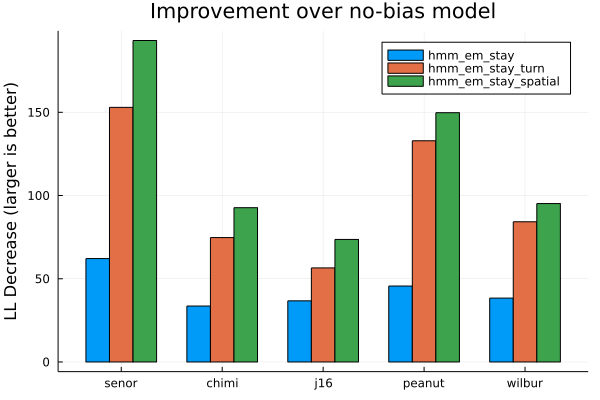

In [20]:
groupedbar(
    likelihoods[:,1] .- likelihoods[:,2:4],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels=["hmm_em_stay" "hmm_em_stay_turn" "hmm_em_stay_spatial"],
    legend=:topright,
    ylabel="LL Decrease (larger is better)",
    title="Improvement over no-bias model",
    # ylabel="Improvement over 'no-bias' model",
    # title="Betas (No fixed effects)"
)

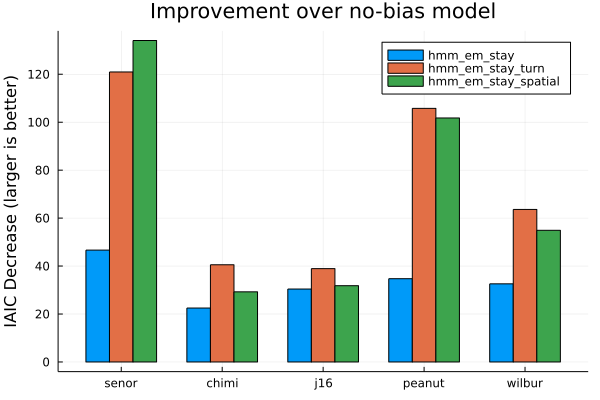

In [21]:
groupedbar(
    iaics[:,1] .- iaics[:,2:4],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels=["hmm_em_stay" "hmm_em_stay_turn" "hmm_em_stay_spatial"],
    legend=:topright,
    ylabel="IAIC Decrease (larger is better)",
    title="Improvement over no-bias model",
    # ylabel="Improvement over 'no-bias' model",
    # title="Betas (No fixed effects)"
)

In [28]:
results[("senor", "hmm_em_stay_turn")].betas[5]

-0.325772412821567

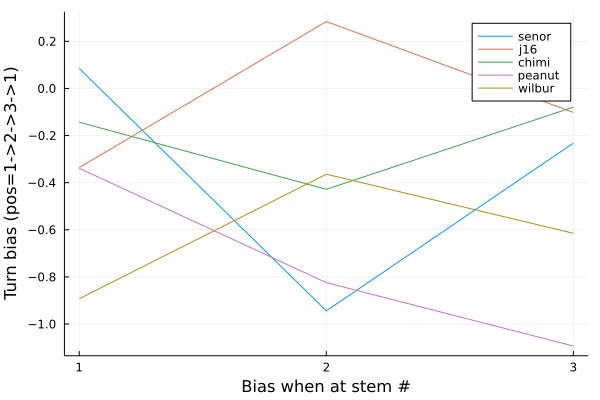

In [48]:
p = plot()
plot!(results[("senor", "hmm_em_stay_spatial")].betas[5:7], label="senor")
plot!(results[("j16", "hmm_em_stay_spatial")].betas[5:7], label="j16")
plot!(results[("chimi", "hmm_em_stay_spatial")].betas[5:7], label="chimi")
plot!(results[("peanut", "hmm_em_stay_spatial")].betas[5:7], label="peanut")
plot!(results[("wilbur", "hmm_em_stay_spatial")].betas[5:7], label="wilbur")
ylabel!("Turn bias (pos=1->2->3->1)")
xticks!([1,2,3])
xlabel!("Bias when at stem #")
p

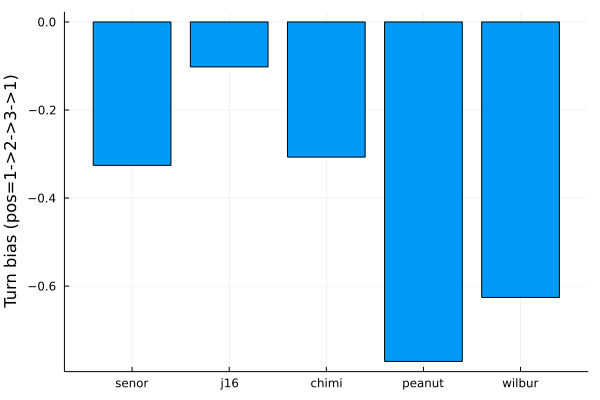

In [41]:
p = plot()
bar!(["senor", "j16", "chimi", "peanut", "wilbur"],
    [results[("senor", "hmm_em_stay_turn")].betas[5],
      results[("j16", "hmm_em_stay_turn")].betas[5],
      results[("chimi", "hmm_em_stay_turn")].betas[5],
      results[("peanut", "hmm_em_stay_turn")].betas[5],
      results[("wilbur", "hmm_em_stay_turn")].betas[5]],
label=nothing)
ylabel!("Turn bias (pos=1->2->3->1)")
p

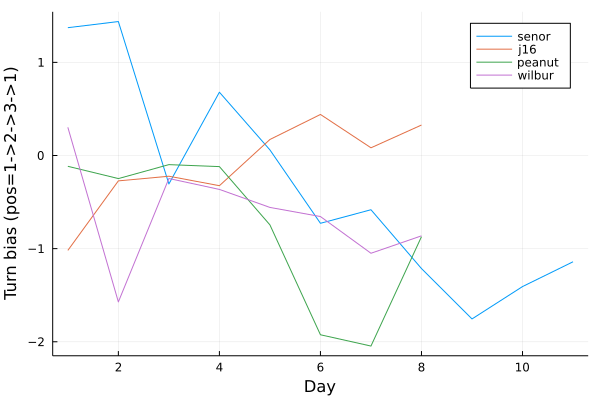

In [85]:
p = plot()
plot!(results[("senor", "hmm_em_stay_turn")].x[:,5], label="senor")
plot!(results[("j16", "hmm_em_stay_turn")].x[:,5], label="j16")
# plot!(results[("chimi", "hmm_em_stay_turn")].x[:,5], label="chimi")
plot!(results[("peanut", "hmm_em_stay_turn")].x[:,5], label="peanut")
plot!(results[("wilbur", "hmm_em_stay_turn")].x[:,5], label="wilbur")
ylabel!("Turn bias (pos=1->2->3->1)")
xlabel!("Day")
p

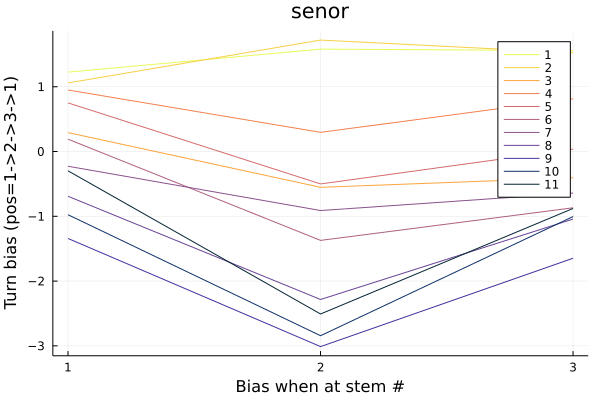

In [81]:
p = plot()
for day in 1:11
    plot!(results[("senor", "hmm_em_stay_spatial")].x[day, 5:7], label=day, palette=palette(:thermal, 11, rev=true))
end
ylabel!("Turn bias (pos=1->2->3->1)")
xticks!([1,2,3])
xlabel!("Bias when at stem #")
title!("senor")
p

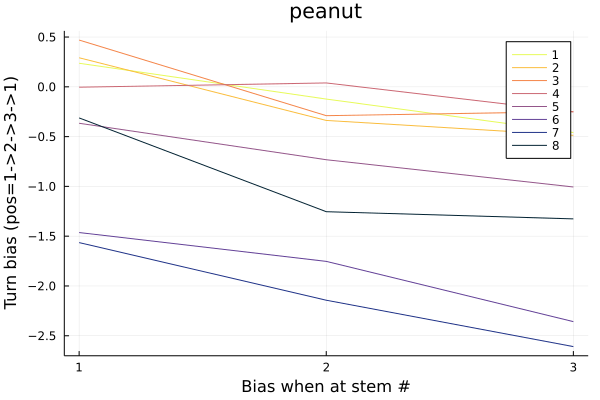

In [82]:
p = plot()
for day in 1:8
    plot!(results[("peanut", "hmm_em_stay_spatial")].x[day, 5:7], label=day, palette=palette(:thermal, 8, rev=true))
end
ylabel!("Turn bias (pos=1->2->3->1)")
xticks!([1,2,3])
xlabel!("Bias when at stem #")
title!("peanut")
p

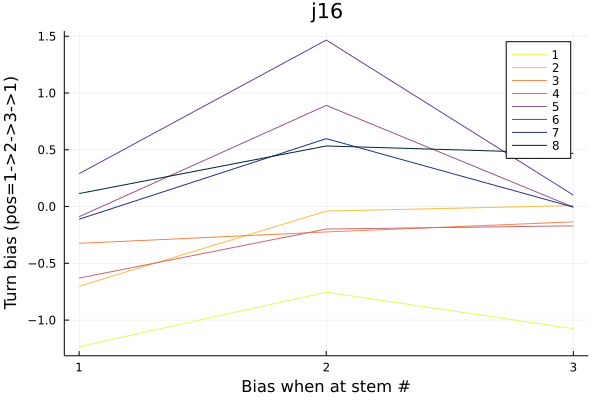

In [83]:
p = plot()
for day in 1:8
    plot!(results[("j16", "hmm_em_stay_spatial")].x[day, 5:7], label=day, palette=palette(:thermal, 8, rev=true))
end
ylabel!("Turn bias (pos=1->2->3->1)")
xticks!([1,2,3])
xlabel!("Bias when at stem #")
title!("j16")
p

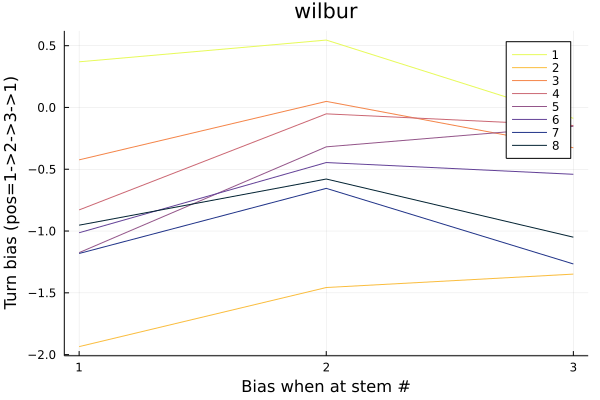

In [84]:
p = plot()
for day in 1:8
    plot!(results[("wilbur", "hmm_em_stay_spatial")].x[day, 5:7], label=day, palette=palette(:thermal, 8, rev=true))
end
ylabel!("Turn bias (pos=1->2->3->1)")
xticks!([1,2,3])
xlabel!("Bias when at stem #")
title!("wilbur")
p